In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('crop_production.csv')
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [4]:
df.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

In [5]:
df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [6]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [7]:
df['Yield'] = df['Production'] / df['Area']

In [8]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


Total West Bengal Data Points are 9613

In [9]:
# wb_count = 0

# for i in df['State_Name']:
#     if i == 'West Bengal':
#         wb_count+=1
#         print(wb_count)           

<Axes: xlabel='Area', ylabel='Production'>

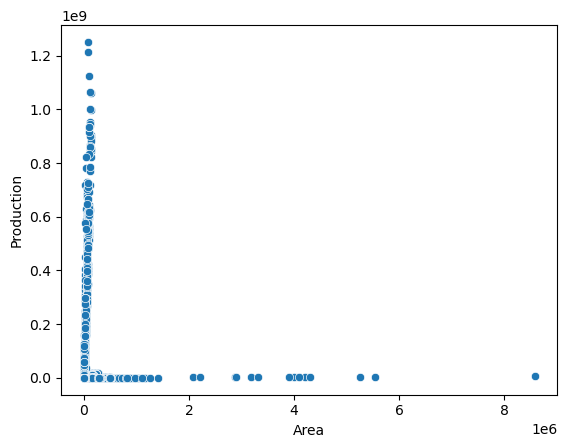

In [10]:
sns.scatterplot(x=df["Area"], y=df["Production"])

In [11]:
df["Crop"].value_counts().head(10)

Crop
Rice                 15104
Maize                13947
Moong(Green Gram)    10318
Urad                  9850
Sesamum               9046
Groundnut             8834
Sugarcane             7921
Wheat                 7899
Rapeseed &Mustard     7592
Arhar/Tur             7578
Name: count, dtype: int64

<Axes: xlabel='Season'>

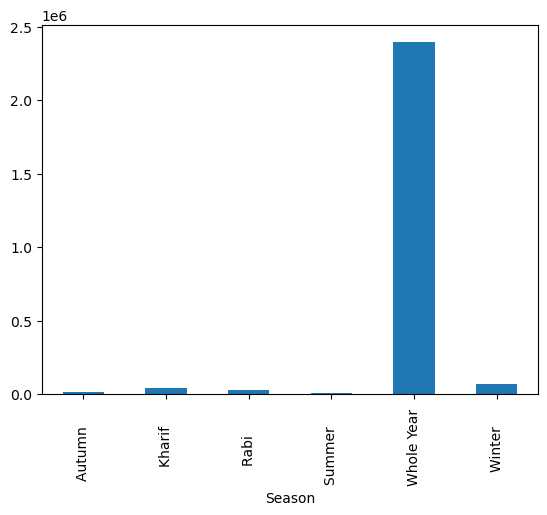

In [12]:
df.groupby("Season")["Production"].mean().plot(kind="bar")

In [13]:
df.groupby("State_Name")["Production"].sum().sort_values(ascending=False).head(10)

State_Name
Kerala                         9.788005e+10
Andhra Pradesh                 1.732459e+10
Tamil Nadu                     1.207644e+10
Uttar Pradesh                  3.234493e+09
Assam                          2.111752e+09
West Bengal                    1.397904e+09
Maharashtra                    1.263641e+09
Karnataka                      8.634298e+08
Andaman and Nicobar Islands    7.182232e+08
Punjab                         5.863850e+08
Name: Production, dtype: float64

<Axes: xlabel='Crop_Year'>

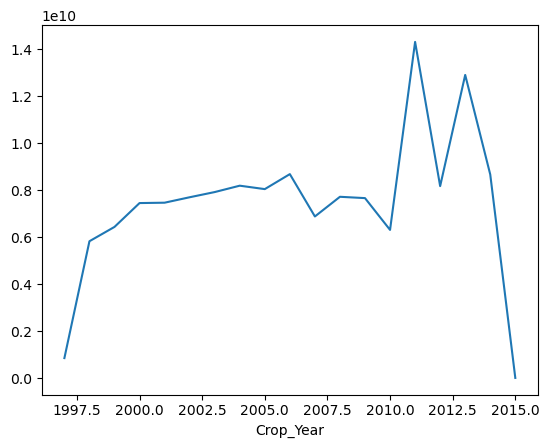

In [14]:
df.groupby("Crop_Year")["Production"].sum().plot()

<Axes: ylabel='Yield'>

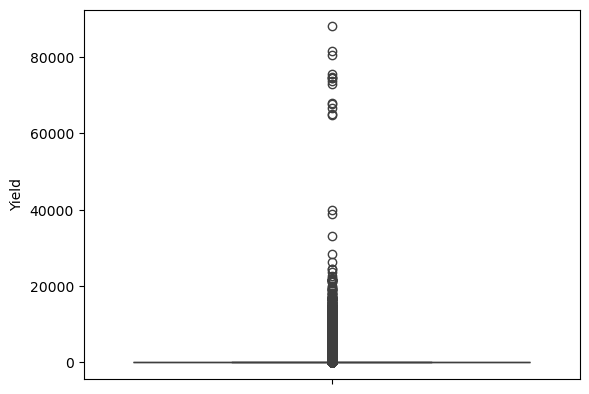

In [15]:
sns.boxplot(df["Yield"])

In [16]:
df = df[df["Yield"] < df["Yield"].quantile(0.99)]

<Axes: ylabel='Yield'>

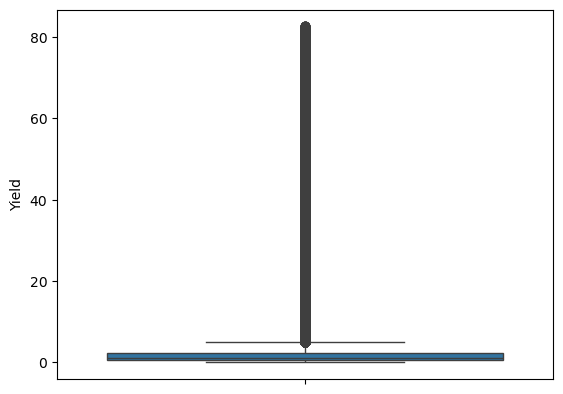

In [17]:
sns.boxplot(df["Yield"])

<Axes: xlabel='Crop_Year'>

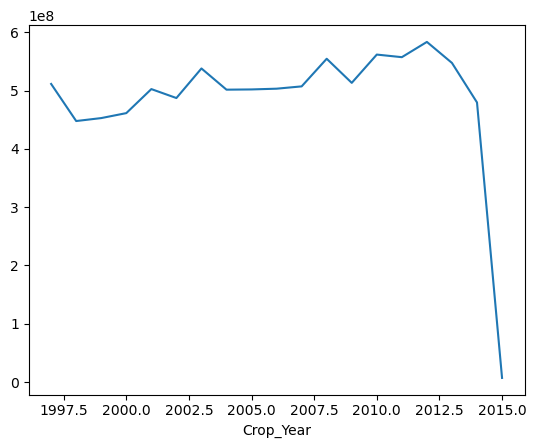

In [18]:
df.groupby("Crop_Year")["Production"].sum().plot()

In [28]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [29]:
state_encode = LabelEncoder()
district_encode = LabelEncoder()
season_encode = LabelEncoder()
crop_encode = LabelEncoder()

df["State"] = state_encode.fit_transform(df["State_Name"])
df["District"] = district_encode.fit_transform(df["District_Name"])
df["Season_enc"] = season_encode.fit_transform(df["Season"])
df["Crop_enc"] = crop_encode.fit_transform(df["Crop"])

In [30]:
df_work = df.copy()
df_work = df_work.drop(['State_Name','District_Name','Season','Crop'],axis=1)

In [31]:
df_work = df_work[df_work["Yield"] < df_work["Yield"].quantile(0.99)]

#sns.boxplot(df_work['Yield'])

df_work["Yield_log"] = np.log1p(df_work["Yield"])

In [32]:
df_work.columns

Index(['Crop_Year', 'Area', 'Production', 'Yield', 'State', 'District',
       'Season_enc', 'Crop_enc', 'Yield_log'],
      dtype='object')

In [36]:
df_work["Yield_log"] = np.log1p(df_work["Yield"])

X = df_work[["State", "District", "Crop_Year", "Season_enc", "Crop_enc", "Area"]]
y = df_work["Yield_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [38]:
model = XGBRegressor(n_estimators=350,learning_rate=0.1,max_depth=9,subsample=0.8, colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.938106229845611
MAE: 0.1296213978167965
RMSE: 0.20098879498781635


In [40]:
df_plot = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

fig = px.scatter(
    df_plot,
    x="Actual",
    y="Predicted",
    title="Actual vs Predicted Yield",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=df_plot["Actual"].min(),
    y0=df_plot["Actual"].min(),
    x1=df_plot["Actual"].max(),
    y1=df_plot["Actual"].max(),
    line=dict(dash="dash")
)

fig.show()

In [41]:
residuals = y_test - y_pred

df_res = pd.DataFrame({
    "Predicted": y_pred,
    "Residuals": residuals
})

fig = px.scatter(
    df_res,
    x="Predicted",
    y="Residuals",
    title="Residual Plot",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=df_res["Predicted"].min(),
    y0=0,
    x1=df_res["Predicted"].max(),
    y1=0,
    line=dict(dash="dash")
)

fig.show()

In [42]:
fig = px.histogram(
    residuals,
    nbins=50,
    title="Residual Distribution"
)

fig.show()

In [43]:
importance = model.feature_importances_
features = X.columns

df_work = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(df_work)

      Feature  Importance
4    Crop_enc    0.602140
3  Season_enc    0.222123
0       State    0.124406
2   Crop_Year    0.021930
5        Area    0.017563
1    District    0.011839


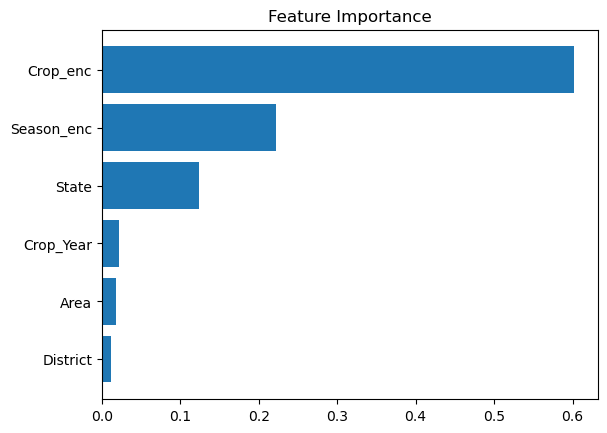

In [44]:
plt.barh(df_work["Feature"], df_work["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [ ]:
# import joblib

# joblib.dump(model, "xgb_yield_model.pkl")
# joblib.dump(state_encode, "staate_encode.pkl")
# joblib.dump(district_encode, "district_encode.pkl")
# joblib.dump(season_encode, "season_encode.pkl")
# joblib.dump(crop_encode, "crop_encode.pkl")

['crop_encode.pkl']